In [43]:
# === Controlauto 1 | Semana 1 — Setup ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = Path("/Users/catarinatorres/Documents/ControlAuto/Data/Raw")  # se os ficheiros estiverem noutra pasta, muda aqui
OUTPUT_DIR = DATA_DIR / "controlauto_outputs"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

def find_file(patterns):
    for pat in patterns:
        matches = glob.glob(str(DATA_DIR / pat))
        if matches:
            return matches[0]
    return None

PATHS = {
    "marcacoes": find_file(["*Marcac*oes*.csv","*Marcações*.csv","*Marcações*.csv","*Marcacoes*.csv"]),
    "producao":  find_file(["*Produc*ao*.csv","*Produção*.csv","*Produção*.csv","*Producao*.csv"]),
    "slots":     find_file(["*Slots*disponiveis*.csv","*Slotsdispon*veis*.csv","*Slots*.csv"]),
    "centros":   find_file(["*Coordenadas*centros*.xlsx","*Coordenadas*.xlsx"]),
}

PATHS

{'marcacoes': '/Users/catarinatorres/Documents/ControlAuto/Data/Raw/Marcações.csv',
 'producao': '/Users/catarinatorres/Documents/ControlAuto/Data/Raw/Produção.csv',
 'slots': '/Users/catarinatorres/Documents/ControlAuto/Data/Raw/Slotsdisponiveis.csv',
 'centros': '/Users/catarinatorres/Documents/ControlAuto/Data/Raw/Coordenadas centros.xlsx'}

In [44]:
def read_csv_auto(path, nrows=None):
    # tenta separadores comuns e encoding UTF-8; fallback latin1
    for sep in [",", ";", "\t", "|"]:
        try:
            df = pd.read_csv(path, sep=sep, nrows=nrows, encoding="utf-8", low_memory=False)
            if df.shape[1] > 1:
                return df
        except Exception:
            pass
    return pd.read_csv(path, nrows=nrows, encoding="latin1", low_memory=False)

df_mar = read_csv_auto(PATHS["marcacoes"])
df_prod = read_csv_auto(PATHS["producao"])
df_slots = read_csv_auto(PATHS["slots"])
centros = pd.read_excel(PATHS["centros"])

print("Marcações:", df_mar.shape)
print("Produção:", df_prod.shape)
print("Slots:", df_slots.shape)
print("Centros:", centros.shape)

df_mar.head(3)


Marcações: (2165673, 6)
Produção: (6783174, 2)
Slots: (1164209, 4)
Centros: (227, 4)


,DiaMarcação,HoraMarcação,CodCentro,Estado,DiaAgendamento,MeioMarcação
0,2025-06-30 00:00:00.000,2025-06-30 13:00:00.000,27,Falta,2025-06-25 12:41:52.570,Site
1,2022-01-15 00:00:00.000,2022-01-15 12:00:00.000,176,Checkin,2022-01-15 07:54:19.810,Site
2,2022-07-12 00:00:00.000,2022-07-12 08:00:00.000,192,Checkin,2022-07-11 16:01:06.613,Outros


In [45]:
display(df_prod.head(10))
display(df_prod.sample(10, random_state=42))
df_prod.info()


,CFGCENTROID,DATA_RECEPCAO
0,20,2022-01-03 07:00:11.000
1,12,2022-01-03 07:02:47.000
2,12,2022-01-03 07:04:05.000
3,20,2022-01-03 07:05:36.000
4,12,2022-01-03 07:11:10.000
5,20,2022-01-03 07:22:19.000
6,90,2022-01-03 07:26:55.000
7,12,2022-01-03 07:27:42.000
8,20,2022-01-03 07:33:07.000
9,90,2022-01-03 07:33:18.000


,CFGCENTROID,DATA_RECEPCAO
1938702,29,2023-03-14 09:21:26.000
4424304,84,2024-08-21 17:19:49.000
5925593,84,2025-06-27 10:59:37.000
3632654,134,2024-03-13 10:47:01.000
4142653,213,2024-06-22 10:57:32.000
5572215,190,2025-04-23 15:40:03.000
1942424,19,2023-03-14 15:00:41.000
6134769,86,2025-08-07 15:14:20.000
3723553,18,2024-04-01 10:39:53.000
1742189,27,2023-01-31 17:01:48.000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6783174 entries, 0 to 6783173
Data columns (total 2 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   CFGCENTROID    int64 
 1   DATA_RECEPCAO  object
dtypes: int64(1), object(1)
memory usage: 103.5+ MB


In [46]:
audit = {
    "n_rows": len(df_prod),
    "n_cols": df_prod.shape[1],
    "missing_CFGCENTROID": int(df_prod["CFGCENTROID"].isna().sum()),
    "missing_DATA_RECEPCAO": int(df_prod["DATA_RECEPCAO"].isna().sum()),
    "n_centros_distintos": int(df_prod["CFGCENTROID"].nunique()),
    "data_min": df_prod["DATA_RECEPCAO"].min(),
    "data_max": df_prod["DATA_RECEPCAO"].max(),
    "duplicados_exatos": int(df_prod.duplicated().sum()),
}

pd.Series(audit)


n_rows                                   6783174
n_cols                                         2
missing_CFGCENTROID                            0
missing_DATA_RECEPCAO                          0
n_centros_distintos                           51
data_min                 2022-01-03 07:00:11.000
data_max                 2025-12-31 15:58:42.000
duplicados_exatos                           1240
dtype: object

In [47]:
data_dictionary_prod = pd.DataFrame(
    [
        {
            "variavel": "CFGCENTROID",
            "descricao": "Identificador do centro (chave primária do centro).",
            "tipo": str(df_prod["CFGCENTROID"].dtype),
            "nota": "Sem missing. Deve ligar a 'Coordenadas centros.xlsx'.",
        },
        {
            "variavel": "DATA_RECEPCAO",
            "descricao": "Timestamp do evento (receção/inspeção).",
            "tipo": str(df_prod["DATA_RECEPCAO"].dtype),
            "nota": "Sem missing. Define a granularidade original (evento).",
        },
    ]
)

data_dictionary_prod


,variavel,descricao,tipo,nota
0,CFGCENTROID,Identificador do centro (chave primária do cen...,int64,Sem missing. Deve ligar a 'Coordenadas centros...
1,DATA_RECEPCAO,Timestamp do evento (receção/inspeção).,object,Sem missing. Define a granularidade original (...


In [48]:
df_prod["DATA_RECEPCAO"] = pd.to_datetime(
    df_prod["DATA_RECEPCAO"],
    errors="coerce",      # converte inválidos para NaT (não rebenta a pipeline)
    dayfirst=True         # Portugal: dd/mm/yyyy é frequente
)

df_prod["DATA_RECEPCAO"].isna().sum(), df_prod["DATA_RECEPCAO"].dtype


(4127776, dtype('<M8[ns]'))

In [49]:
df_prod = df_prod.assign(
    data=df_prod["DATA_RECEPCAO"].dt.date,
    hora=df_prod["DATA_RECEPCAO"].dt.floor("H"),
    dow=df_prod["DATA_RECEPCAO"].dt.dayofweek,  # 0=segunda, 6=domingo
)

df_prod[["CFGCENTROID", "DATA_RECEPCAO", "data", "hora", "dow"]].head()


/var/folders/qv/x09m5tcj2_7fj12rwqd1whnc0000gn/T/ipykernel_53536/1449619554.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hora=df_prod["DATA_RECEPCAO"].dt.floor("H"),


,CFGCENTROID,DATA_RECEPCAO,data,hora,dow
0,20,2022-03-01 07:00:11,2022-03-01,2022-03-01 07:00:00,1.0
1,12,2022-03-01 07:02:47,2022-03-01,2022-03-01 07:00:00,1.0
2,12,2022-03-01 07:04:05,2022-03-01,2022-03-01 07:00:00,1.0
3,20,2022-03-01 07:05:36,2022-03-01,2022-03-01 07:00:00,1.0
4,12,2022-03-01 07:11:10,2022-03-01,2022-03-01 07:00:00,1.0


In [50]:
# Horária: centro × hora
core_hourly = (
    df_prod.groupby(["CFGCENTROID", "hora"], as_index=False)
           .size()
           .rename(columns={"size": "y_eventos"})
)

# Diária: centro × dia
core_daily = (
    df_prod.groupby(["CFGCENTROID", "data"], as_index=False)
           .size()
           .rename(columns={"size": "y_eventos"})
)

# Mensal: centro × mês
df_prod["mes"] = df_prod["DATA_RECEPCAO"].dt.to_period("M").dt.to_timestamp()
core_monthly = (
    df_prod.groupby(["CFGCENTROID", "mes"], as_index=False)
           .size()
           .rename(columns={"size": "y_eventos"})
)

(core_hourly.shape, core_daily.shape, core_monthly.shape)


((246918, 3), (23865, 3), (2448, 3))

In [51]:
display(df_slots.head(10))
display(df_slots.sample(10, random_state=42))
df_slots.info()


,Date,Hours,AvailableSlots,CodCentro
0,2024-03-18 00:00:00.000,2024-03-18 15:45:00.000,2,4
1,2024-03-18 00:00:00.000,2024-03-18 10:00:00.000,2,9
2,2024-03-18 00:00:00.000,2024-03-18 10:45:00.000,2,9
3,2024-03-18 00:00:00.000,2024-03-18 18:45:00.000,2,9
4,2024-03-18 00:00:00.000,2024-03-18 12:30:00.000,2,10
5,2024-03-18 00:00:00.000,2024-03-18 14:00:00.000,2,10
6,2024-03-18 00:00:00.000,2024-03-18 14:15:00.000,2,10
7,2024-03-18 00:00:00.000,2024-03-18 12:15:00.000,3,12
8,2024-03-18 00:00:00.000,2024-03-18 14:50:00.000,3,12
9,2024-03-18 00:00:00.000,2024-03-18 12:30:00.000,2,13


,Date,Hours,AvailableSlots,CodCentro
923845,2025-08-14 00:00:00.000,2025-08-14 11:00:00.000,2,13
734109,2025-04-28 00:00:00.000,2025-04-28 14:10:00.000,2,178
651994,2025-03-11 00:00:00.000,2025-03-11 17:30:00.000,3,34
800803,2025-06-04 00:00:00.000,2025-06-04 15:45:00.000,2,15
1090622,2025-11-17 00:00:00.000,2025-11-17 11:00:00.000,3,190
1110437,2025-11-27 00:00:00.000,2025-11-27 15:00:00.000,2,35
780570,2025-05-23 00:00:00.000,2025-05-23 08:45:00.000,2,15
563348,2025-01-22 00:00:00.000,2025-01-22 09:30:00.000,2,178
1022315,2025-10-09 00:00:00.000,2025-10-09 16:45:00.000,2,13
94450,2024-05-08 00:00:00.000,2024-05-08 18:00:00.000,2,35


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1164209 entries, 0 to 1164208
Data columns (total 4 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   Date            1164209 non-null  object
 1   Hours           1164209 non-null  object
 2   AvailableSlots  1164209 non-null  int64 
 3   CodCentro       1164209 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 35.5+ MB


In [52]:
audit_slots = pd.Series({
    "n_rows": len(df_slots),
    "n_cols": df_slots.shape[1],
    "duplicados_exatos": int(df_slots.duplicated().sum()),
})

missing_slots = df_slots.isna().sum().sort_values(ascending=False)

audit_slots, missing_slots.head(15)


(n_rows               1164209
 n_cols                     4
 duplicados_exatos          0
 dtype: int64,
 Date              0
 Hours             0
 AvailableSlots    0
 CodCentro         0
 dtype: int64)

In [53]:
date_like_cols = [c for c in df_slots.columns if any(k in c.upper() for k in ["DATA", "DATE", "HORA", "TIME"])]
date_like_cols
for c in date_like_cols:
    df_slots[c] = pd.to_datetime(df_slots[c], errors="coerce", dayfirst=True)

pd.DataFrame({
    "coluna": date_like_cols,
    "dtype": [str(df_slots[c].dtype) for c in date_like_cols],
    "na": [int(df_slots[c].isna().sum()) for c in date_like_cols],
})


/var/folders/qv/x09m5tcj2_7fj12rwqd1whnc0000gn/T/ipykernel_53536/2434351940.py:4: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_slots[c] = pd.to_datetime(df_slots[c], errors="coerce", dayfirst=True)


,coluna,dtype,na
0,Date,datetime64[ns],0


In [54]:
# Eliminar os domingos do dataframe prod:
# dayofweek: 0=segunda ... 6=domingo
df_prod = df_prod[df_prod["DATA_RECEPCAO"].dt.dayofweek != 6].copy()

pd.Series({
    "n_rows_pos_exclusao_domingo": len(df_prod),
    "data_min": df_prod["DATA_RECEPCAO"].min(),
    "data_max": df_prod["DATA_RECEPCAO"].max(),
})


n_rows_pos_exclusao_domingo                6388014
data_min                       2022-01-03 07:28:14
data_max                       2025-12-12 19:40:16
dtype: object

In [55]:
# Criar coluna base:
df_prod = df_prod.assign(
    hora=df_prod["DATA_RECEPCAO"].dt.floor("h"),
    data=df_prod["DATA_RECEPCAO"].dt.date
)

df_prod[["CFGCENTROID", "DATA_RECEPCAO", "hora", "data"]].head()


,CFGCENTROID,DATA_RECEPCAO,hora,data
0,20,2022-03-01 07:00:11,2022-03-01 07:00:00,2022-03-01
1,12,2022-03-01 07:02:47,2022-03-01 07:00:00,2022-03-01
2,12,2022-03-01 07:04:05,2022-03-01 07:00:00,2022-03-01
3,20,2022-03-01 07:05:36,2022-03-01 07:00:00,2022-03-01
4,12,2022-03-01 07:11:10,2022-03-01 07:00:00,2022-03-01


In [56]:
#Agregação horária:
hourly_counts = (
    df_prod
    .groupby(["CFGCENTROID", "hora"], as_index=False)
    .size()
    .rename(columns={"size": "y_inspecoes"})
)

hourly_counts.head(), hourly_counts.shape


(   CFGCENTROID                hora  y_inspecoes
 0            4 2022-01-03 08:00:00            5
 1            4 2022-01-03 09:00:00            4
 2            4 2022-01-03 10:00:00            4
 3            4 2022-01-03 11:00:00            2
 4            4 2022-01-03 14:00:00            2,
 (209418, 3))

In [57]:
# Contruir grelha completa sem domingos:
# intervalo horário global
hour_range = pd.date_range(
    start=hourly_counts["hora"].min(),
    end=hourly_counts["hora"].max(),
    freq="h"
)

# remover domingos da grelha (semanas de 6 dias)
hour_range = hour_range[hour_range.dayofweek != 6]

centros = hourly_counts["CFGCENTROID"].unique()

full_hour_grid = (
    pd.MultiIndex.from_product([centros, hour_range], names=["CFGCENTROID", "hora"])
    .to_frame(index=False)
)

full_hour_grid.head(), full_hour_grid.shape


(   CFGCENTROID                hora
 0            4 2022-01-03 07:00:00
 1            4 2022-01-03 08:00:00
 2            4 2022-01-03 09:00:00
 3            4 2022-01-03 10:00:00
 4            4 2022-01-03 11:00:00,
 (1511079, 2))

In [58]:
#Merge mais zeros excluidos:
core_hourly = (
    full_hour_grid
    .merge(hourly_counts, on=["CFGCENTROID", "hora"], how="left")
    .fillna({"y_inspecoes": 0})
)

core_hourly["y_inspecoes"] = core_hourly["y_inspecoes"].astype(int)

# sanity checks
pd.Series({
    "n_rows_core_hourly": len(core_hourly),
    "n_centros": int(core_hourly["CFGCENTROID"].nunique()),
    "hora_min": core_hourly["hora"].min(),
    "hora_max": core_hourly["hora"].max(),
    "zeros_pct": float((core_hourly["y_inspecoes"] == 0).mean()),
})


n_rows_core_hourly                1511079
n_centros                              51
hora_min              2022-01-03 07:00:00
hora_max              2025-12-12 19:00:00
zeros_pct                        0.861412
dtype: object

In [59]:
# Features para depois usar para EDA:
core_hourly = core_hourly.assign(
    data=core_hourly["hora"].dt.date,
    dow=core_hourly["hora"].dt.dayofweek,  # 0=segunda ... 5=sábado (domingo não existe)
    hour_of_day=core_hourly["hora"].dt.hour,
    month=core_hourly["hora"].dt.month,
    year=core_hourly["hora"].dt.year,
)

core_hourly.head()


,CFGCENTROID,hora,y_inspecoes,data,dow,hour_of_day,month,year
0,4,2022-01-03 07:00:00,0,2022-01-03,0,7,1,2022
1,4,2022-01-03 08:00:00,5,2022-01-03,0,8,1,2022
2,4,2022-01-03 09:00:00,4,2022-01-03,0,9,1,2022
3,4,2022-01-03 10:00:00,4,2022-01-03,0,10,1,2022
4,4,2022-01-03 11:00:00,2,2022-01-03,0,11,1,2022


In [60]:
#Derivar dataset diário:
core_daily = (
    core_hourly
    .groupby(["CFGCENTROID", "data"], as_index=False)["y_inspecoes"]
    .sum()
)

core_daily["data"] = pd.to_datetime(core_daily["data"])
core_daily = core_daily.assign(
    dow=core_daily["data"].dt.dayofweek,
    is_saturday=(core_daily["data"].dt.dayofweek == 5).astype(int),
    week=core_daily["data"].dt.isocalendar().week.astype(int),
    month=core_daily["data"].dt.month,
    year=core_daily["data"].dt.year,
)

core_daily.head(), core_daily.shape


(   CFGCENTROID       data  y_inspecoes  dow  is_saturday  week  month  year
 0            4 2022-01-03           20    0            0     1      1  2022
 1            4 2022-01-04           30    1            0     1      1  2022
 2            4 2022-01-05            0    2            0     1      1  2022
 3            4 2022-01-06           53    3            0     1      1  2022
 4            4 2022-01-07           63    4            0     1      1  2022,
 (62985, 8))

In [61]:
#Derivar dataset mensal:
core_monthly = (
    core_daily
    .assign(mes=core_daily["data"].dt.to_period("M").dt.to_timestamp())
    .groupby(["CFGCENTROID", "mes"], as_index=False)["y_inspecoes"]
    .sum()
)

core_monthly.head(), core_monthly.shape


(   CFGCENTROID        mes  y_inspecoes
 0            4 2022-01-01          258
 1            4 2022-02-01          376
 2            4 2022-03-01          429
 3            4 2022-04-01          416
 4            4 2022-05-01          420,
 (2448, 3))

In [62]:
#Guardar as novas versões
PATH_CORE_HOURLY = OUTPUT_DIR/ "data_core_hourly_v1.csv"
PATH_CORE_DAILY  = OUTPUT_DIR/ "data_core_daily_v1.csv"
PATH_CORE_MONTHLY = OUTPUT_DIR/ "data_core_monthly_v1.csv"

core_hourly.to_csv(PATH_CORE_HOURLY, index=False)
core_daily.to_csv(PATH_CORE_DAILY, index=False)
core_monthly.to_csv(PATH_CORE_MONTHLY, index=False)

PATH_CORE_HOURLY, PATH_CORE_DAILY, PATH_CORE_MONTHLY



(PosixPath('/Users/catarinatorres/Documents/ControlAuto/Data/Raw/controlauto_outputs/data_core_hourly_v1.csv'),
 PosixPath('/Users/catarinatorres/Documents/ControlAuto/Data/Raw/controlauto_outputs/data_core_daily_v1.csv'),
 PosixPath('/Users/catarinatorres/Documents/ControlAuto/Data/Raw/controlauto_outputs/data_core_monthly_v1.csv'))

In [63]:
core_hourly = core_hourly.sort_values(["CFGCENTROID", "hora"]).reset_index(drop=True)

core_hourly.dtypes


CFGCENTROID             int64
hora           datetime64[ns]
y_inspecoes             int64
data                   object
dow                     int32
hour_of_day             int32
month                   int32
year                    int32
dtype: object

In [64]:
# Perfil horário médio:
profile_hour = (
    core_hourly
    .groupby("hour_of_day", as_index=False)["y_inspecoes"]
    .mean()
)

profile_hour


,hour_of_day,y_inspecoes
0,0,0.000000
1,1,0.000000
2,2,0.000000
3,3,0.000000
4,4,0.000000
5,5,0.000000
6,6,0.001414
7,7,0.252822
8,8,2.858395
9,9,4.070572


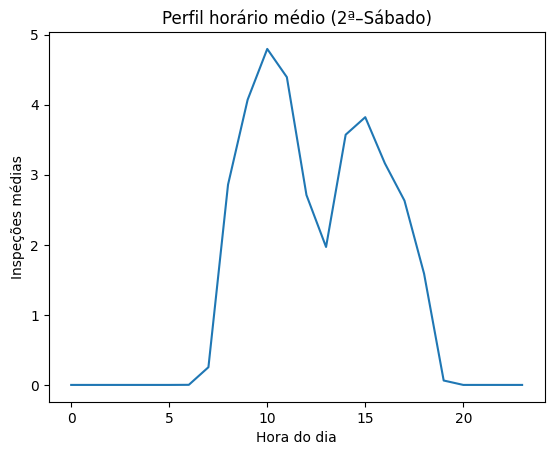

In [65]:
# Gráfico de visualização:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(profile_hour["hour_of_day"], profile_hour["y_inspecoes"])
plt.xlabel("Hora do dia")
plt.ylabel("Inspeções médias")
plt.title("Perfil horário médio (2ª–Sábado)")
plt.show()


In [66]:
#Perfil hora vs dia da semana:
profile_dow_hour = (
    core_hourly
    .groupby(["dow", "hour_of_day"], as_index=False)["y_inspecoes"]
    .mean()
)

profile_dow_hour.head()


,dow,hour_of_day,y_inspecoes
0,0,0,0.0
1,0,1,0.0
2,0,2,0.0
3,0,3,0.0
4,0,4,0.0


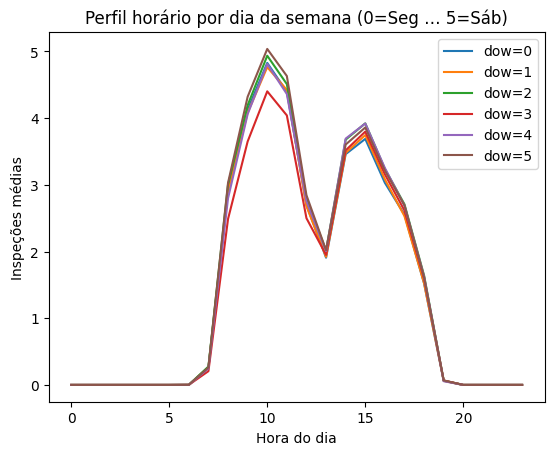

In [67]:
# Gráfico:
for d in sorted(profile_dow_hour["dow"].unique()):
    tmp = profile_dow_hour[profile_dow_hour["dow"] == d]
    plt.plot(tmp["hour_of_day"], tmp["y_inspecoes"], label=f"dow={d}")

plt.xlabel("Hora do dia")
plt.ylabel("Inspeções médias")
plt.title("Perfil horário por dia da semana (0=Seg … 5=Sáb)")
plt.legend()
plt.show()


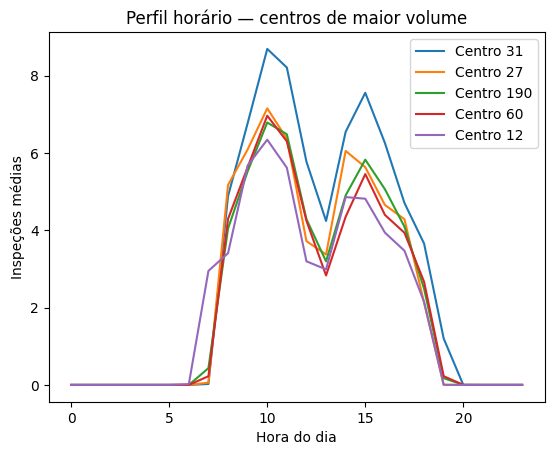

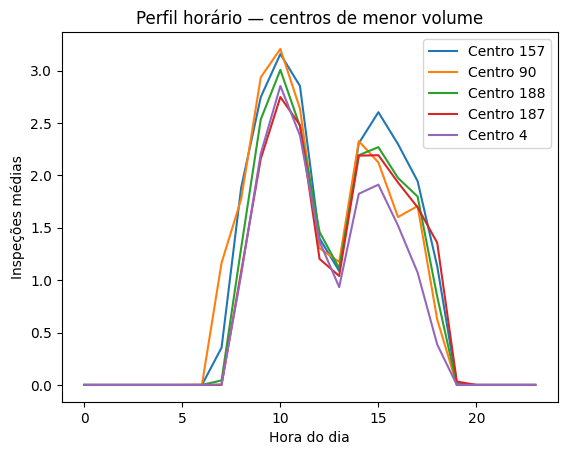

In [68]:
# Comparar centros grandes ou pequenos:
volume_por_centro = (
    core_hourly
    .groupby("CFGCENTROID", as_index=False)["y_inspecoes"]
    .sum()
    .sort_values("y_inspecoes", ascending=False)
)

top_centros = volume_por_centro.head(5)["CFGCENTROID"]
bottom_centros = volume_por_centro.tail(5)["CFGCENTROID"]

def plot_centros(lista_centros, titulo):
    plt.figure()
    for c in lista_centros:
        tmp = (
            core_hourly[core_hourly["CFGCENTROID"] == c]
            .groupby("hour_of_day")["y_inspecoes"]
            .mean()
        )
        plt.plot(tmp.index, tmp.values, label=f"Centro {c}")
    plt.title(titulo)
    plt.xlabel("Hora do dia")
    plt.ylabel("Inspeções médias")
    plt.legend()
    plt.show()

plot_centros(top_centros, "Perfil horário — centros de maior volume")
plot_centros(bottom_centros, "Perfil horário — centros de menor volume")



In [69]:
# Análise do ruido do zero:
zero_rate = (
    core_hourly
    .groupby("hour_of_day")["y_inspecoes"]
    .apply(lambda x: (x == 0).mean())
    .reset_index(name="pct_zero")
)

zero_rate


,hour_of_day,pct_zero
0,0,1.000000
1,1,1.000000
2,2,1.000000
3,3,1.000000
4,4,1.000000
5,5,1.000000
6,6,0.998697
7,7,0.910598
8,8,0.680638
9,9,0.678765


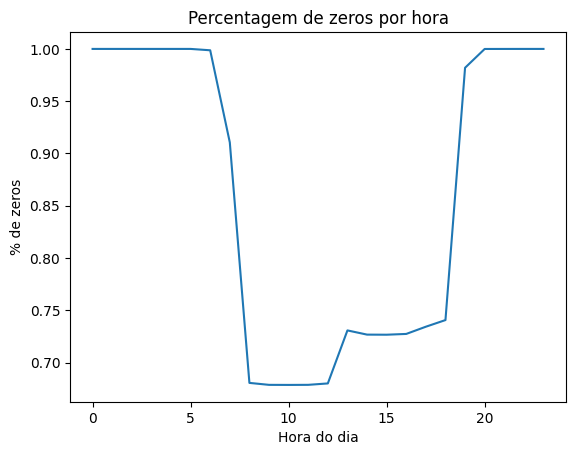

In [70]:
#Gráfico:
plt.figure()
plt.plot(zero_rate["hour_of_day"], zero_rate["pct_zero"])
plt.xlabel("Hora do dia")
plt.ylabel("% de zeros")
plt.title("Percentagem de zeros por hora")
plt.show()


In [71]:
core_daily = core_daily.sort_values(["CFGCENTROID", "data"]).reset_index(drop=True)
core_monthly = core_monthly.sort_values(["CFGCENTROID", "mes"]).reset_index(drop=True)

core_daily.dtypes, core_monthly.dtypes


(CFGCENTROID             int64
 data           datetime64[ns]
 y_inspecoes             int64
 dow                     int32
 is_saturday             int64
 week                    int64
 month                   int32
 year                    int32
 dtype: object,
 CFGCENTROID             int64
 mes            datetime64[ns]
 y_inspecoes             int64
 dtype: object)

In [72]:
#Existe sazonalidade semanal?
daily_dow = (
    core_daily
    .groupby("dow", as_index=False)["y_inspecoes"]
    .mean()
)

daily_dow


,dow,y_inspecoes
0,0,35.457453
1,1,35.453931
2,2,36.968399
3,3,33.977822
4,4,36.268704
5,5,37.192061


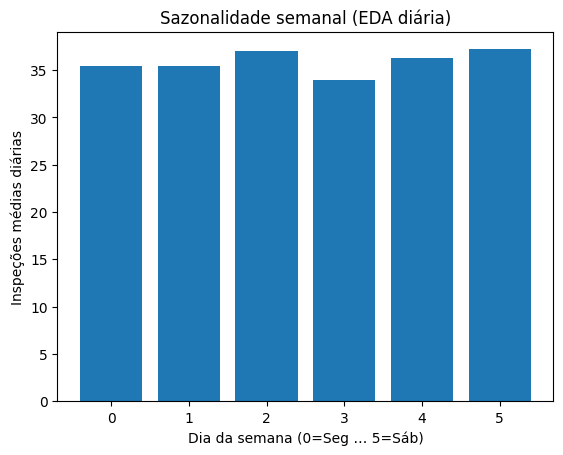

In [73]:
# Gráfico:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(daily_dow["dow"], daily_dow["y_inspecoes"])
plt.xlabel("Dia da semana (0=Seg … 5=Sáb)")
plt.ylabel("Inspeções médias diárias")
plt.title("Sazonalidade semanal (EDA diária)")
plt.show()


In [74]:
# Estabilidade ao longo do tempo:
daily_global = (
    core_daily
    .groupby("data", as_index=False)["y_inspecoes"]
    .sum()
)

daily_global.head()


,data,y_inspecoes
0,2022-01-03,2245
1,2022-01-04,4939
2,2022-01-05,0
3,2022-01-06,5899
4,2022-01-07,6184


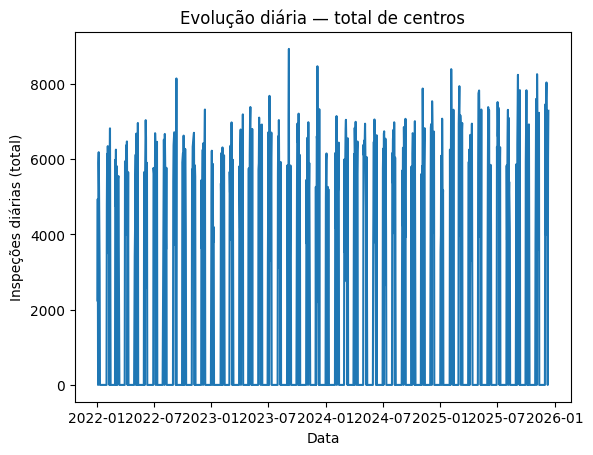

In [75]:
plt.figure()
plt.plot(daily_global["data"], daily_global["y_inspecoes"])
plt.xlabel("Data")
plt.ylabel("Inspeções diárias (total)")
plt.title("Evolução diária — total de centros")
plt.show()


In [76]:
# Heterogenidade entre centros:
stats_centros = (
    core_daily
    .groupby("CFGCENTROID")["y_inspecoes"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

stats_centros.head(), stats_centros.tail()


(                  mean         std
 CFGCENTROID                       
 31           68.509312  103.076330
 27           54.680162   84.339260
 190          53.302024   81.942257
 60           51.516599   78.928298
 12           49.429150   74.502459,
                   mean        std
 CFGCENTROID                      
 157          23.782186  35.950448
 90           22.587045  34.249838
 188          21.012146  31.994793
 187          20.108502  30.846925
 4            17.518219  26.652186)

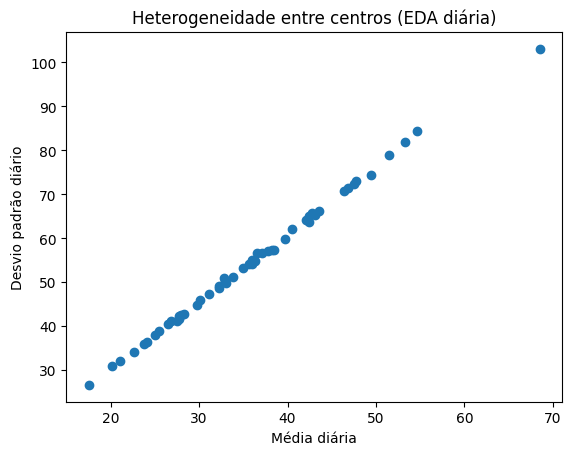

In [77]:
#Gráfico:
plt.figure()
plt.scatter(stats_centros["mean"], stats_centros["std"])
plt.xlabel("Média diária")
plt.ylabel("Desvio padrão diário")
plt.title("Heterogeneidade entre centros (EDA diária)")
plt.show()


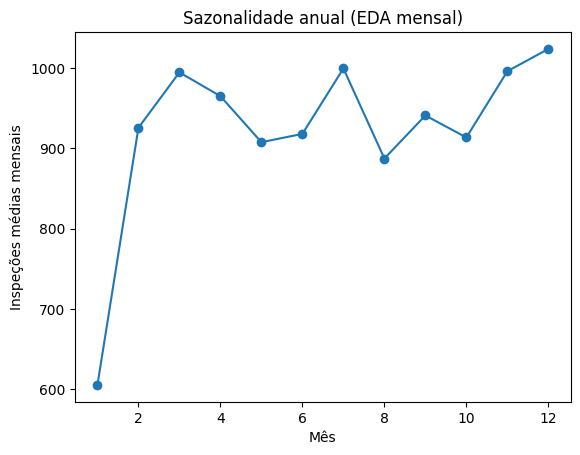

In [78]:
#Sazonalidade Anual:
monthly_profile = (
    core_monthly
    .assign(mes_num=core_monthly["mes"].dt.month)
    .groupby("mes_num", as_index=False)["y_inspecoes"]
    .mean()
)

monthly_profile

plt.figure()
plt.plot(monthly_profile["mes_num"], monthly_profile["y_inspecoes"], marker="o")
plt.xlabel("Mês")
plt.ylabel("Inspeções médias mensais")
plt.title("Sazonalidade anual (EDA mensal)")
plt.show()



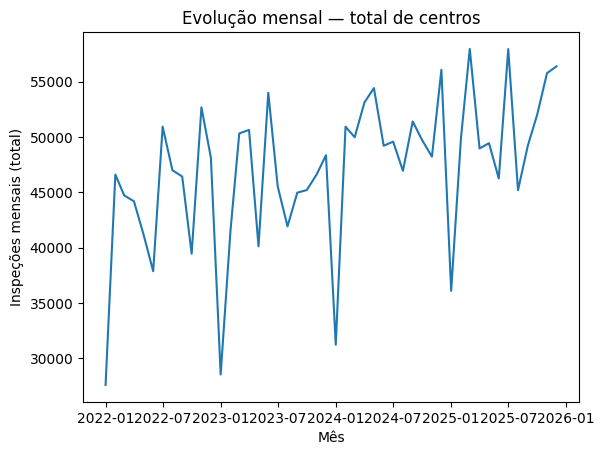

In [79]:
#EDA Mensal:
monthly_global = (
    core_monthly
    .groupby("mes", as_index=False)["y_inspecoes"]
    .sum()
)

plt.figure()
plt.plot(monthly_global["mes"], monthly_global["y_inspecoes"])
plt.xlabel("Mês")
plt.ylabel("Inspeções mensais (total)")
plt.title("Evolução mensal — total de centros")
plt.show()


In [80]:
hour_stats = core_hourly["y_inspecoes"].describe()
hour_stats

q99 = core_hourly["y_inspecoes"].quantile(0.99)

outliers_hour = core_hourly[core_hourly["y_inspecoes"] > q99]

outliers_hour.head(), len(outliers_hour)


(       CFGCENTROID                hora  y_inspecoes        data  dow  hour_of_day  month  year
 30332            9 2022-02-05 14:00:00           25  2022-02-05    5           14      2  2022
 30908            9 2022-03-05 14:00:00           22  2022-03-05    5           14      3  2022
 32104            9 2022-05-03 10:00:00           26  2022-05-03    1           10      5  2022
 32206            9 2022-05-07 16:00:00           21  2022-05-07    5           16      5  2022
 32709            9 2022-06-01 15:00:00           21  2022-06-01    2           15      6  2022,
 12857)

In [81]:
daily_global = (
    core_daily
    .groupby("data", as_index=False)["y_inspecoes"]
    .sum()
)

q99_daily = daily_global["y_inspecoes"].quantile(0.99)

outliers_daily = daily_global[daily_global["y_inspecoes"] > q99_daily]

outliers_daily


,data,y_inspecoes
216,2022-09-12,8144
524,2023-09-06,8929
602,2023-12-06,8468
890,2024-11-06,7876
968,2025-02-05,8391
990,2025-03-03,7939
1043,2025-05-03,7748
1044,2025-05-05,7824
1151,2025-09-06,8240
1156,2025-09-12,7833


In [82]:
#Outliers por centro:
center_stats = (
    core_daily
    .groupby("CFGCENTROID")["y_inspecoes"]
    .agg(["mean", "std", "max"])
    .sort_values("max", ascending=False)
)

center_stats.head(10)

# centros cujo máximo diário é desproporcional face à média
center_stats["ratio_max_mean"] = center_stats["max"] / center_stats["mean"]
center_stats.sort_values("ratio_max_mean", ascending=False).head(10)


,mean,std,max,ratio_max_mean
CFGCENTROID,,,,
188,21.012146,31.994793,137,6.520039
90,22.587045,34.249838,142,6.286790
16,27.693927,41.706549,171,6.174639
239,24.138462,36.451265,146,6.048438
57,30.112551,45.890658,180,5.977574
13,34.965992,53.150261,207,5.920038
134,42.753846,65.728403,250,5.847427
92,26.510121,40.558086,153,5.771381
187,20.108502,30.846925,116,5.768704


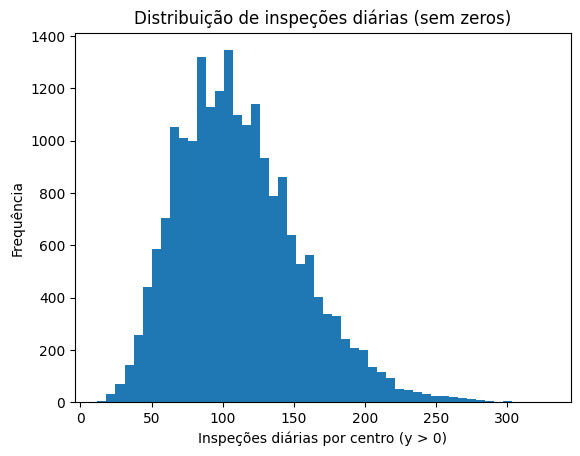

In [83]:
positivos = core_daily[core_daily["y_inspecoes"] > 0]["y_inspecoes"]

plt.figure()
plt.hist(positivos, bins=50)
plt.xlabel("Inspeções diárias por centro (y > 0)")
plt.ylabel("Frequência")
plt.title("Distribuição de inspeções diárias (sem zeros)")
plt.show()


<Figure size 640x480 with 0 Axes>

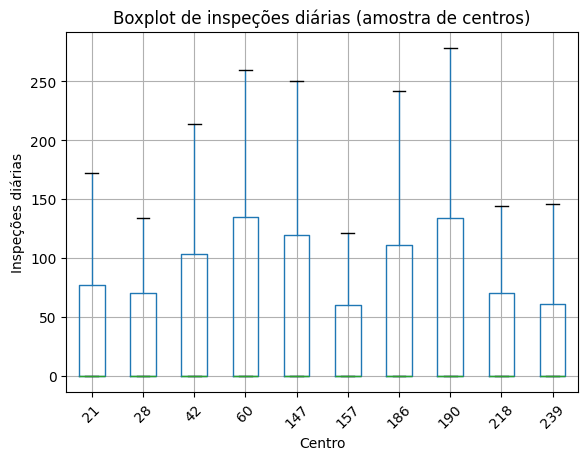

In [84]:
import numpy as np

sample_centros = np.random.choice(
    core_daily["CFGCENTROID"].unique(),
    size=min(10, core_daily["CFGCENTROID"].nunique()),
    replace=False
)

plt.figure()
core_daily[core_daily["CFGCENTROID"].isin(sample_centros)] \
    .boxplot(column="y_inspecoes", by="CFGCENTROID", rot=45)
plt.title("Boxplot de inspeções diárias (amostra de centros)")
plt.suptitle("")
plt.xlabel("Centro")
plt.ylabel("Inspeções diárias")
plt.show()
